In [24]:
# =========================================
# 📌 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import joblib

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\YUVRAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
# =========================================
# 📌 2. LOAD DATASET
# =========================================
df = pd.read_csv(
    "Amazon_Reviews.csv",
    engine='python',
    encoding='latin1',
    on_bad_lines='skip'
)

df.columns = df.columns.str.strip()

# Select required columns
df = df[['Review Text', 'Rating']]

df.dropna(inplace=True)

# Rename
df.columns = ['review', 'rating']

print(df.head())

                                              review                  rating
0  I registered on the website, tried to order a ...  Rated 1 out of 5 stars
1  Had multiple orders one turned up and driver h...  Rated 1 out of 5 stars
2  I informed these reprobates that I WOULD NOT B...  Rated 1 out of 5 stars
3  I have bought from Amazon before and no proble...  Rated 1 out of 5 stars
4  If I could give a lower rate I would! I cancel...  Rated 1 out of 5 stars


In [26]:
# =========================================
# 📌 3. CONVERT RATING TO NUMERIC
# =========================================
df['rating'] = df['rating'].astype(str).str.extract(r'(\d+\.?\d*)')
df['rating'] = df['rating'].astype(float)

print(df['rating'].unique())

[1. 5. 2. 4. 3.]


In [27]:
# =========================================
# 📌 4. CREATE SENTIMENT LABEL
# =========================================
def label_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating <= 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['rating'].apply(label_sentiment)

print(df['sentiment'].value_counts())

sentiment
negative    14350
positive     5820
neutral       885
Name: count, dtype: int64


In [30]:
# =========================================
# 📌 5. CLEAN DATA
# =========================================

df = df[df['review'].str.strip() != ""]

In [31]:
# =========================================
# 📌 7. TEXT CLEANING
# =========================================

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df["cleaned_review"] = df["review"].apply(clean_text)

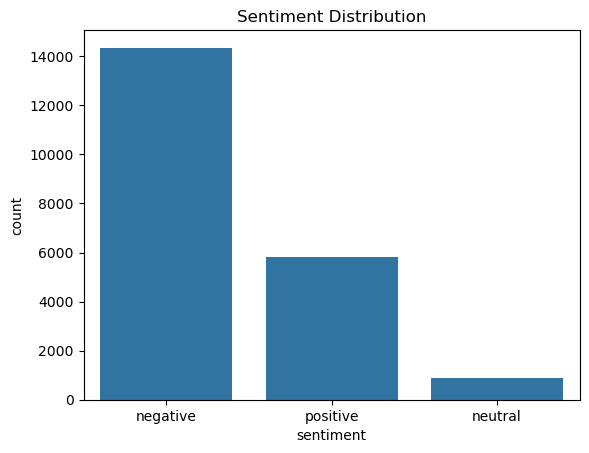

In [32]:
# =========================================
# 📊 5. EDA
# =========================================

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

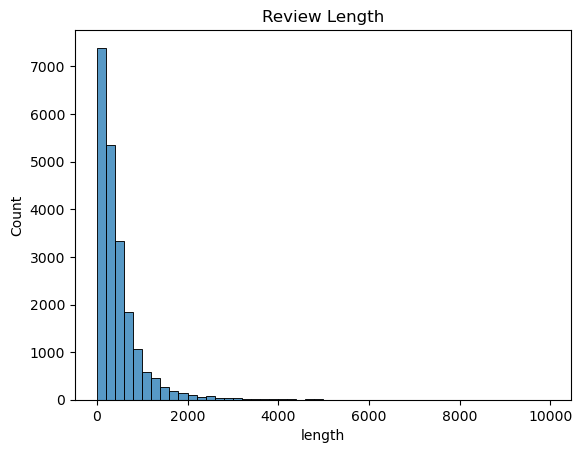

In [33]:
df['length'] = df['review'].apply(len)

sns.histplot(df['length'], bins=50)
plt.title("Review Length")
plt.show()

In [34]:
# =========================================
# 6. FEATURE ENGINEERING
# =========================================

# =========================================
#  TF-IDF
# =========================================

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["cleaned_review"])
y = df["sentiment"]

print(X.shape)

(21055, 5000)


In [35]:
# =========================================
# 📌 7. TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
# =========================================
# 📌 8. MODEL TRAINING
# =========================================

# =========================================
# 📌 11. MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

In [37]:
# =========================================
# 📌 12. EVALUATION
# =========================================

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print(results_df.sort_values(by="F1 Score", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.905723   0.909024  0.905723  0.887963
2                  SVM  0.900974   0.881155  0.900974  0.886624
1          Naive Bayes  0.889337   0.853928  0.889337  0.869731


In [38]:
# =========================================
# 🏆 10. BEST MODEL
# =========================================

results_df.sort_values(by="F1 Score", ascending=False, inplace=True)

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [40]:
# =========================================
# 📌 1. FINAL EVALUATION
# =========================================
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

    negative       0.92      0.97      0.94      2921
     neutral       1.00      0.01      0.02       166
    positive       0.86      0.88      0.87      1124

    accuracy                           0.91      4211
   macro avg       0.93      0.62      0.61      4211
weighted avg       0.91      0.91      0.89      4211



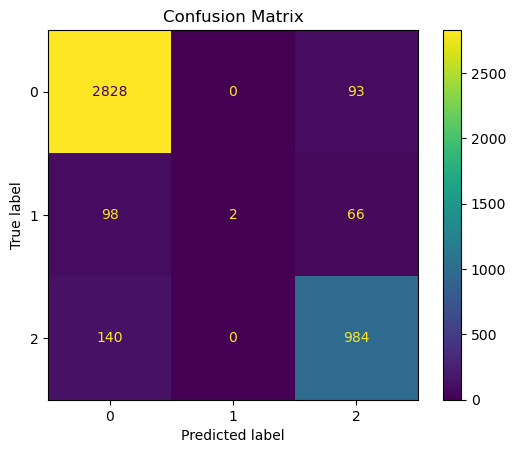

In [41]:
# =========================================
# 📌 2. CONFUSION MATRIX
# =========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [42]:
# =========================================
# 📌 3. MANUAL TEST
# =========================================

sample_reviews = [
    "This product is amazing, I love it!",
    "Worst product ever, waste of money",
    "It's okay, not great but not bad"
]

for review in sample_reviews:
    cleaned = clean_text(review)
    vectorized = tfidf.transform([cleaned])
    prediction = best_model.predict(vectorized)[0]
    
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {prediction}")
    print("-" * 50)

Review: This product is amazing, I love it!
Predicted Sentiment: positive
--------------------------------------------------
Review: Worst product ever, waste of money
Predicted Sentiment: negative
--------------------------------------------------
Review: It's okay, not great but not bad
Predicted Sentiment: positive
--------------------------------------------------


In [44]:
import os
import joblib

# Create model folder in current directory
os.makedirs("model", exist_ok=True)

joblib.dump(best_model, "model/sentiment_model.pkl")
joblib.dump(tfidf, "model/vectorizer.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
